In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

##### Load dữ liệu đã xử lý (từ 03_preprocessing.ipynb)

In [21]:
import joblib

# Import train/val/test đã scale + scaler đã lưu từ 03_preprocessing.ipynb thay vì lặp lại pipeline
train_scaled = pd.read_csv('data/processed/train_scaled.csv', index_col='time', parse_dates=True)
val_scaled = pd.read_csv('data/processed/val_scaled.csv', index_col='time', parse_dates=True)
test_scaled = pd.read_csv('data/processed/test_scaled.csv', index_col='time', parse_dates=True)
scaler = joblib.load('data/processed/scaler.joblib')

feature_cols = train_scaled.columns.tolist()
pm25_col_idx = feature_cols.index('PM2.5')
n_features = len(feature_cols)

print(f"Train: {len(train_scaled)} dòng | Val: {len(val_scaled)} dòng | Test: {len(test_scaled)} dòng")
print(f"Feature columns ({n_features}): {feature_cols}")

Train: 24405 dòng | Val: 5230 dòng | Test: 5230 dòng
Feature columns (11): ['PM10', 'PM2.5', 'Carbon Monoxide', 'Nitrogen Dioxide', 'Sulphur Dioxide', 'Ozone', 'Aerosol Optical Depth', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


c:\Users\l20f9\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


##### Model & Training Utilities

In [22]:
def create_sequences(data, target_col_idx, window_size, horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size + horizon - 1, target_col_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


def train_model(train_scaled, val_scaled, pm25_col_idx, window_size, hidden_size=32,
                 num_layers=2, dropout=0.2, lr=1e-3, batch_size=256,
                 max_epochs=20, patience=4, device='cpu', verbose=False):
    X_train, y_train = create_sequences(train_scaled.values, pm25_col_idx, window_size)
    X_val, y_val = create_sequences(val_scaled.values, pm25_col_idx, window_size)

    train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TimeSeriesDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    model = GRUModel(input_size=X_train.shape[2], hidden_size=hidden_size,
                      num_layers=num_layers, dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                val_losses.append(criterion(pred, yb).item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if verbose:
            print(f"  Epoch {epoch + 1}/{max_epochs} - train_loss={train_loss:.5f}, val_loss={val_loss:.5f}")

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val_loss, history

##### Hyperparameter Tuning: Window Size

In [23]:
# Grid search window_size dựa trên 3 ứng viên đã bàn ở 02_eda.ipynb (chu kỳ ngày-đêm đã xác nhận qua
# ACF/PACF & Periodogram, không có weekly seasonality nên không cần thử window dài hơn 72h).
# Các hyperparameter khác giữ cố định để search chỉ tập trung vào câu hỏi "window size bao nhiêu là đủ".
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

window_candidates = [24, 48, 72]
search_results = []

for ws in window_candidates:
    print(f"Đang thử window_size={ws}h...")
    _, val_loss, _ = train_model(
        train_scaled, val_scaled, pm25_col_idx,
        window_size=ws, hidden_size=32, max_epochs=6, patience=2, device=device,
    )
    search_results.append({'window_size': ws, 'val_loss': val_loss})
    print(f"  -> best val_loss (MSE, thang đo scaled) = {val_loss:.5f}")

results_df = pd.DataFrame(search_results).sort_values('val_loss').reset_index(drop=True)
results_df

Device: cpu
Đang thử window_size=24h...
  -> best val_loss (MSE, thang đo scaled) = 0.00068
Đang thử window_size=48h...
  -> best val_loss (MSE, thang đo scaled) = 0.00064
Đang thử window_size=72h...
  -> best val_loss (MSE, thang đo scaled) = 0.00084


,window_size,val_loss
0,48,0.000637
1,24,0.000683
2,72,0.000835


In [24]:
# Chọn window nhỏ nhất trong số các window có val_loss gần mức tốt nhất (trong khoảng dung sai TOLERANCE)
# -> ưu tiên window nhẹ hơn (ít bước tính toán hơn, train/infer nhanh hơn) khi hiệu năng không chênh lệch đáng kể
TOLERANCE = 0.10  # 10%
best_val_loss = results_df['val_loss'].min()
candidates = results_df[results_df['val_loss'] <= best_val_loss * (1 + TOLERANCE)]
BEST_WINDOW = int(candidates.sort_values('window_size').iloc[0]['window_size'])
chosen_val_loss = candidates.sort_values('window_size').iloc[0]['val_loss']

print(f"Các window trong khoảng {TOLERANCE * 100:.0f}% so với tốt nhất ({best_val_loss:.5f}):")
print(candidates.sort_values('window_size').to_string(index=False))
print(f"\nWindow size được chọn: {BEST_WINDOW}h (val_loss={chosen_val_loss:.5f})")

Các window trong khoảng 10% so với tốt nhất (0.00064):
 window_size  val_loss
          24  0.000683
          48  0.000637

Window size được chọn: 24h (val_loss=0.00068)


##### Train Model Cuối Cùng (window size tốt nhất, nhiều epoch hơn)

  Epoch 1/25 - train_loss=0.01579, val_loss=0.00376
  Epoch 2/25 - train_loss=0.00335, val_loss=0.00209
  Epoch 3/25 - train_loss=0.00235, val_loss=0.00161
  Epoch 4/25 - train_loss=0.00190, val_loss=0.00144
  Epoch 5/25 - train_loss=0.00163, val_loss=0.00123
  Epoch 6/25 - train_loss=0.00141, val_loss=0.00110
  Epoch 7/25 - train_loss=0.00125, val_loss=0.00098
  Epoch 8/25 - train_loss=0.00116, val_loss=0.00090
  Epoch 9/25 - train_loss=0.00104, val_loss=0.00084
  Epoch 10/25 - train_loss=0.00094, val_loss=0.00076
  Epoch 11/25 - train_loss=0.00087, val_loss=0.00075
  Epoch 12/25 - train_loss=0.00081, val_loss=0.00072
  Epoch 13/25 - train_loss=0.00077, val_loss=0.00065
  Epoch 14/25 - train_loss=0.00071, val_loss=0.00062
  Epoch 15/25 - train_loss=0.00070, val_loss=0.00061
  Epoch 16/25 - train_loss=0.00066, val_loss=0.00059
  Epoch 17/25 - train_loss=0.00065, val_loss=0.00054
  Epoch 18/25 - train_loss=0.00064, val_loss=0.00057
  Epoch 19/25 - train_loss=0.00062, val_loss=0.00067
  

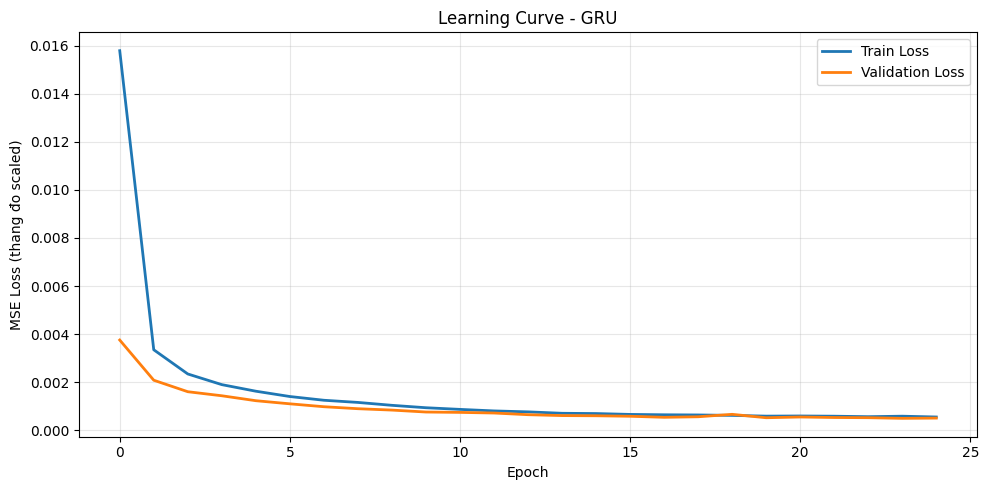

In [25]:
final_model, final_val_loss, history = train_model(
    train_scaled, val_scaled, pm25_col_idx,
    window_size=BEST_WINDOW, hidden_size=32, max_epochs=25, patience=5,
    device=device, verbose=True,
)

plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (thang đo scaled)')
plt.title('Learning Curve - GRU')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Đánh giá trên Test Set: GRU vs Baseline

In [26]:
X_test, y_test = create_sequences(test_scaled.values, pm25_col_idx, BEST_WINDOW)
test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=256, shuffle=False)

final_model.eval()
preds_scaled = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        preds_scaled.append(final_model(xb).cpu().numpy())
preds_scaled = np.concatenate(preds_scaled)


def inverse_transform_col(scaled_values, col_idx, scaler, n_features):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, col_idx] = scaled_values
    return scaler.inverse_transform(dummy)[:, col_idx]


pred_pm25 = inverse_transform_col(preds_scaled, pm25_col_idx, scaler, n_features)
true_pm25 = inverse_transform_col(y_test, pm25_col_idx, scaler, n_features)

# Mốc thời gian tương ứng với từng dự báo: target đầu tiên rơi vào vị trí BEST_WINDOW của test_scaled
target_times = test_scaled.index[BEST_WINDOW:BEST_WINDOW + len(y_test)]

# PM2.5 thang đo gốc cho toàn bộ test set (để tính baseline) - inverse-transform từ test_scaled
test_pm25_series = pd.Series(
    inverse_transform_col(test_scaled['PM2.5'].values, pm25_col_idx, scaler, n_features),
    index=test_scaled.index,
)


def mae_rmse(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse


# Baseline: Naive (giá trị giờ trước) & Seasonal Naive (giá trị cùng giờ hôm qua, lag=24)
# Đánh giá trên CÙNG target_times với GRU để so sánh công bằng
naive_pred = test_pm25_series.shift(1).loc[target_times].values
seasonal_pred = test_pm25_series.shift(24).loc[target_times].values

mae_naive, rmse_naive = mae_rmse(true_pm25, naive_pred)
mae_seasonal, rmse_seasonal = mae_rmse(true_pm25, seasonal_pred)
mae_gru, rmse_gru = mae_rmse(true_pm25, pred_pm25)

comparison = pd.DataFrame({
    'Model': ['Naive (t-1)', 'Seasonal Naive (t-24)', f'GRU (window={BEST_WINDOW}h)'],
    'MAE (µg/m³)': [mae_naive, mae_seasonal, mae_gru],
    'RMSE (µg/m³)': [rmse_naive, rmse_seasonal, rmse_gru],
})
comparison

,Model,MAE (µg/m³),RMSE (µg/m³)
0,Naive (t-1),1.318940,2.360140
1,Seasonal Naive (t-24),4.692221,6.650823
2,GRU (window=24h),1.138274,2.102950


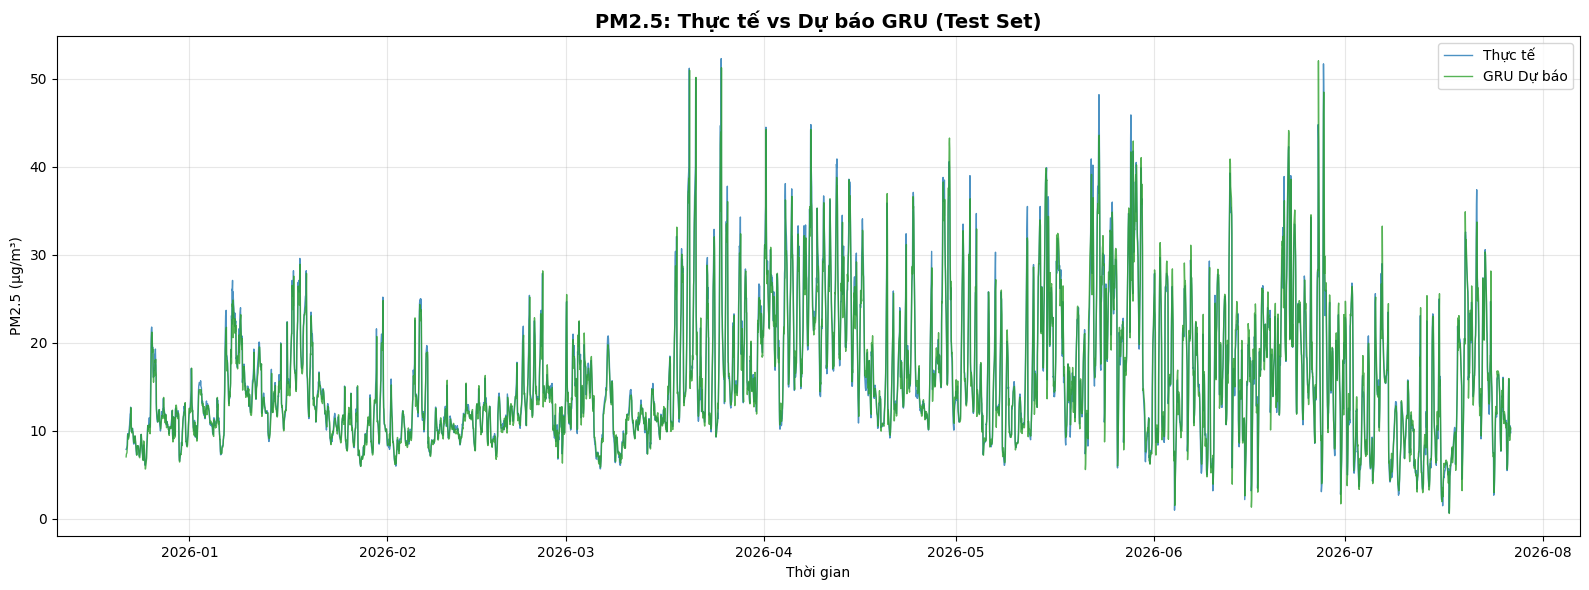

In [27]:
plt.figure(figsize=(16, 6))
plt.plot(target_times, true_pm25, label='Thực tế', color='#1f77b4', alpha=0.8, linewidth=1)
plt.plot(target_times, pred_pm25, label='GRU Dự báo', color='#2ca02c', alpha=0.8, linewidth=1)
plt.xlabel('Thời gian')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('PM2.5: Thực tế vs Dự báo GRU (Test Set)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Residual Diagnostics

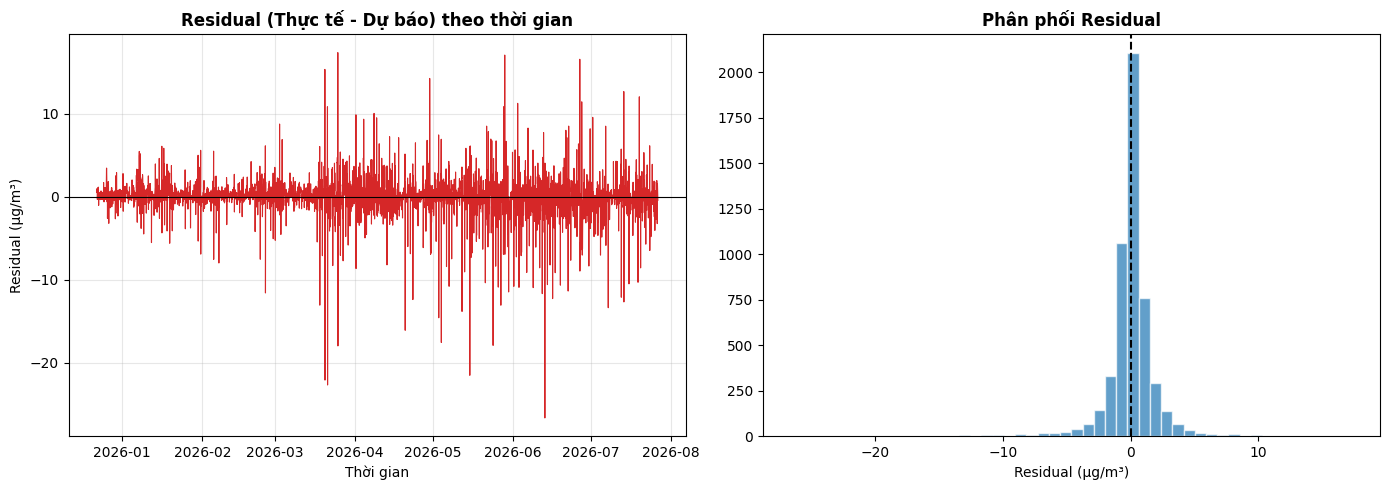

Residual mean: 0.048 µg/m³, std: 2.102 µg/m³


In [28]:
residuals = true_pm25 - pred_pm25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(target_times, residuals, linewidth=0.8, color='#d62728')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Residual (Thực tế - Dự báo) theo thời gian', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Thời gian')
axes[0].set_ylabel('Residual (µg/m³)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=50, color='#1f77b4', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Phân phối Residual', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual (µg/m³)')

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.3f} µg/m³, std: {residuals.std():.3f} µg/m³")